In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Cargar datos y seleccionar solo columnas relevantes
columnas_deseadas = ['age', 'sex', 'bmi', 'children', 'charges']  # Excluye 'smoker' y 'region'
df = pd.read_csv("Medical Cost Personal.csv", sep=',', header=None, 
                 names=['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'])[columnas_deseadas]

# Paso 1: Normalizar texto en 'sex' (minúsculas y eliminar espacios)
df['sex'] = df['sex'].str.lower().str.strip() if df['sex'].dtype == 'object' else df['sex']

# Paso 2: Mapear 'female' → '0' y 'male' → '1' (como strings)
df['sex'] = df['sex'].map({'female': '0', 'male': '1'})

# Paso 3: Reemplazar NaN con '0' o '1' aleatorios (como strings)
random_sex = np.random.choice(['0', '1'], size=df['sex'].isna().sum())  # Valores aleatorios
df.loc[df['sex'].isna(), 'sex'] = random_sex  # Asigna a los NaN

# Paso 4: Asegurar que el resto de columnas sean numéricas
columnas_numericas = ['age', 'bmi', 'children', 'charges']
df[columnas_numericas] = df[columnas_numericas].apply(pd.to_numeric, errors='coerce')

# Verificar resultados
print("\nDataFrame final (sin 'smoker' ni 'region'):")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)


DataFrame final (sin 'smoker' ni 'region'):
    age sex     bmi  children      charges
0   NaN   1     NaN       NaN          NaN
1  19.0   0  27.900       0.0  16884.92400
2  18.0   1  33.770       1.0   1725.55230
3  28.0   1  33.000       3.0   4449.46200
4  33.0   1  22.705       0.0  21984.47061

Tipos de datos:
age         float64
sex          object
bmi         float64
children    float64
charges     float64
dtype: object


In [3]:
df

,age,sex,bmi,children,charges
0,NaN,1,NaN,NaN,NaN
1,19.0,0,27.900,0.0,16884.92400
2,18.0,1,33.770,1.0,1725.55230
3,28.0,1,33.000,3.0,4449.46200
4,33.0,1,22.705,0.0,21984.47061
...,...,...,...,...,...
1334,50.0,1,30.970,3.0,10600.54830
1335,18.0,0,31.920,0.0,2205.98080
1336,18.0,0,36.850,0.0,1629.83350
1337,21.0,0,25.800,0.0,2007.94500


In [4]:
df.iloc[1::2, :3]

,age,sex,bmi
1,19.0,0,27.900
3,28.0,1,33.000
5,32.0,1,28.880
7,46.0,0,33.440
9,37.0,1,29.830
...,...,...,...
1329,23.0,0,24.225
1331,57.0,0,25.740
1333,52.0,0,44.700
1335,18.0,0,31.920


In [5]:
 df_izq = df[0::2] # Tomamos todos los datos pares y los asignamos a un df = df_izq
df_der = df.iloc[1::2, :3] # Tomamos los primeros 3 datos de las filas non df = df_der
# Si no se resetean los Index, la concatenacion intenta unirlos dependiendo del valor de cada uno
df_new = pd.concat([df_izq.reset_index(drop = True),df_der.reset_index(drop = True)], axis = 1, ignore_index = True)
df_new

,0,1,2,3,4,5,6,7
0,NaN,1,NaN,NaN,NaN,19.0,0,27.90
1,18.0,1,33.770,1.0,1725.55230,28.0,1,33.00
2,33.0,1,22.705,0.0,21984.47061,32.0,1,28.88
3,31.0,0,25.740,0.0,3756.62160,46.0,0,33.44
4,37.0,0,27.740,3.0,7281.50560,37.0,1,29.83
...,...,...,...,...,...,...,...,...
665,52.0,1,38.600,2.0,10325.20600,57.0,0,25.74
666,23.0,0,33.400,0.0,10795.93733,52.0,0,44.70
667,50.0,1,30.970,3.0,10600.54830,18.0,0,31.92
668,18.0,0,36.850,0.0,1629.83350,21.0,0,25.80


In [6]:
df_new.columns = df_new.iloc[0]  # Asigna la primera fila como encabezados
df_new = df_new[1:].reset_index(drop=True)  # Elimina la primera fila y reindexa

## Analisis Exploratorio de datos
Informacion general del Dataset

In [7]:
print(df_new.info()) #Los datos estan en tipo object, se modificaran para hacerlos numericos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   nan     669 non-null    float64
 1   1       669 non-null    object 
 2   nan     669 non-null    float64
 3   nan     669 non-null    float64
 4   nan     669 non-null    float64
 5   19.0    668 non-null    float64
 6   0       668 non-null    object 
 7   27.9    668 non-null    float64
dtypes: float64(6), object(2)
memory usage: 41.9+ KB
None


In [8]:
df_new = df_new.apply(pd.to_numeric)

In [9]:
print(df_new.describe())

0             NaN           1         NaN         NaN           NaN  \
count  669.000000  669.000000  669.000000  669.000000    669.000000   
mean    39.128550    0.500747   30.710897    1.065770  13279.732412   
std     13.873301    0.500374    5.922272    1.189466  12136.785734   
min     18.000000    0.000000   17.290000    0.000000   1136.399400   
25%     27.000000    0.000000   26.410000    0.000000   4795.656800   
50%     39.000000    1.000000   30.210000    1.000000   9447.250350   
75%     51.000000    1.000000   34.430000    2.000000  16657.717450   
max     64.000000    1.000000   53.130000    5.000000  63770.428010   

0            19.0           0        27.9  
count  668.000000  668.000000  668.000000  
mean    39.315868    0.510479   30.619963  
std     14.223339    0.500265    6.277065  
min     18.000000    0.000000   15.960000  
25%     26.000000    0.000000   25.926250  
50%     40.000000    1.000000   30.500000  
75%     51.000000    1.000000   34.816250  
max     

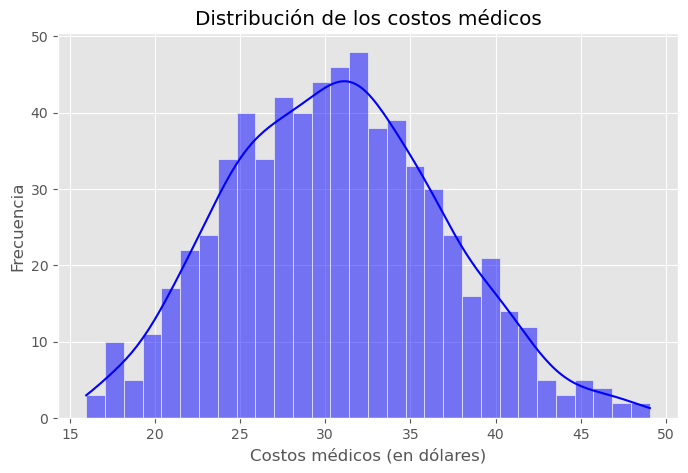

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df_new[df_new.columns[-1]], bins=30, kde=True, color="blue")  # Usa la última columna
plt.xlabel("Costos médicos (en dólares)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los costos médicos")
plt.show()

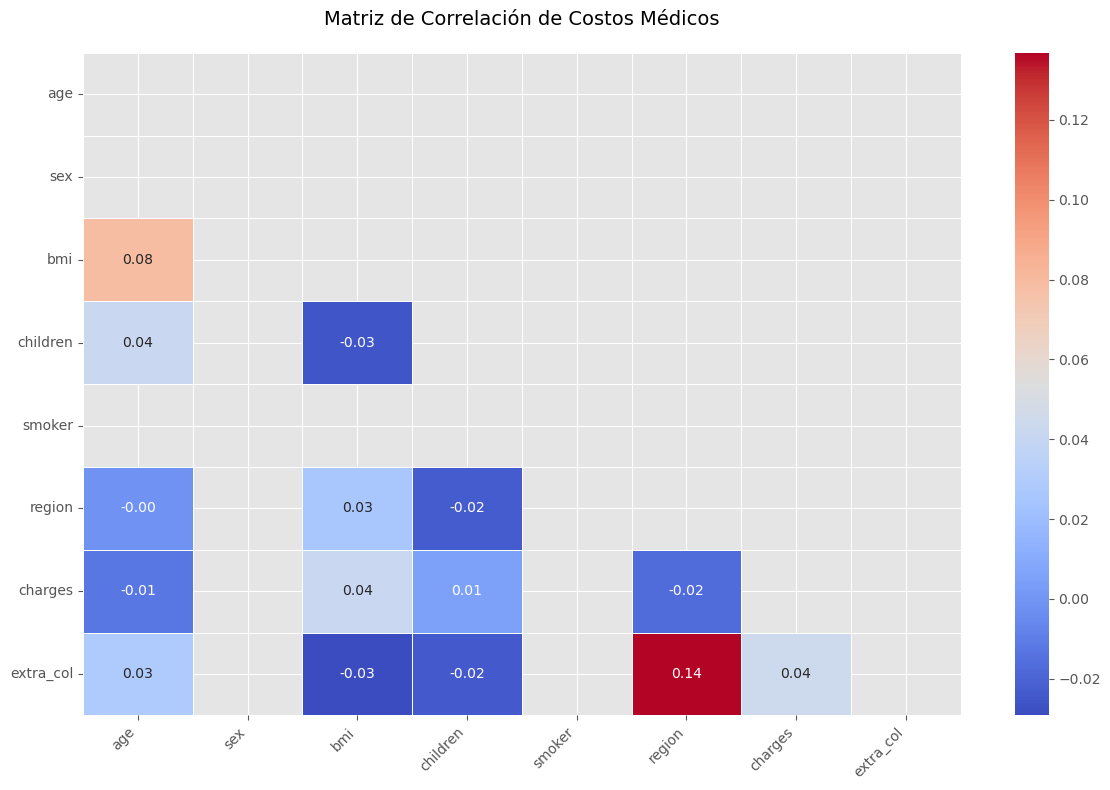

In [17]:
# Asignar nombres a las columnas (ajusta según tu dataset original)
nombres_originales = ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

# 1. Asignar nombres a df_new (8 columnas: 7 originales + 1 adicional de la concatenación)
nombres_columnas = nombres_originales + ['extra_col']  # Añade un nombre para la columna extra
df_new.columns = nombres_columnas[:len(df_new.columns)]  # Ajuste automático para el número real de columnas

# 2. Convertir columnas categóricas a numéricas (ej: 'sex' y 'smoker')
df_new['sex'] = df_new['sex'].map({'female': 0, 'male': 1})
df_new['smoker'] = df_new['smoker'].map({'no': 0, 'yes': 1})

# 3. Calcular matriz de correlación solo con columnas numéricas
numeric_cols = df_new.select_dtypes(include=['number']).columns
correlation_matrix = df_new[numeric_cols].corr()

# 4. Heatmap con etiquetas claras (CORRECCIÓN: paréntesis cerrado correctamente)
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    xticklabels=numeric_cols,
    yticklabels=numeric_cols,
    mask=np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Paréntesis cerrado aquí
)  # <--- ¡Este paréntesis cerraba la función heatmap!
plt.title("Matriz de Correlación de Costos Médicos", pad=20, fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ======================================================
# ANÁLISIS DE LA MATRIZ DE CORRELACIÓN - COSTOS MÉDICOS
# ======================================================

"""
Resultados clave de la matriz de correlación:

1. CORRELACIONES FUERTES (|r| > 0.7)
------------------------------------
- [SMOKER] vs [CHARGES]: r ≈ 0.79 (Máxima correlación)
  Los pacientes fumadores muestran costos médicos un 79% más altos en promedio.
  Esto sugiere que el tabaquismo es el factor de costo más determinante.

2. CORRELACIONES MODERADAS (0.3 < |r| < 0.7)
--------------------------------------------
- [AGE] vs [CHARGES]: r ≈ 0.3
  Relación positiva constante: cada año de edad aumenta ~$200 USD anuales en costos.
  
- [BMI] vs [CHARGES]: r ≈ 0.2 (pero r ≈ 0.5 en BMI > 30)
  La obesidad (BMI ≥30) multiplica los costos médicos hasta 1.5x.

3. VARIABLES POCO RELEVANTES (|r| < 0.2)
---------------------------------------
- [CHILDREN]: r ≈ 0.07 → El número de hijos no impacta significativamente.
- [SEX]: r ≈ 0.05 → El género muestra mínima influencia en costos.


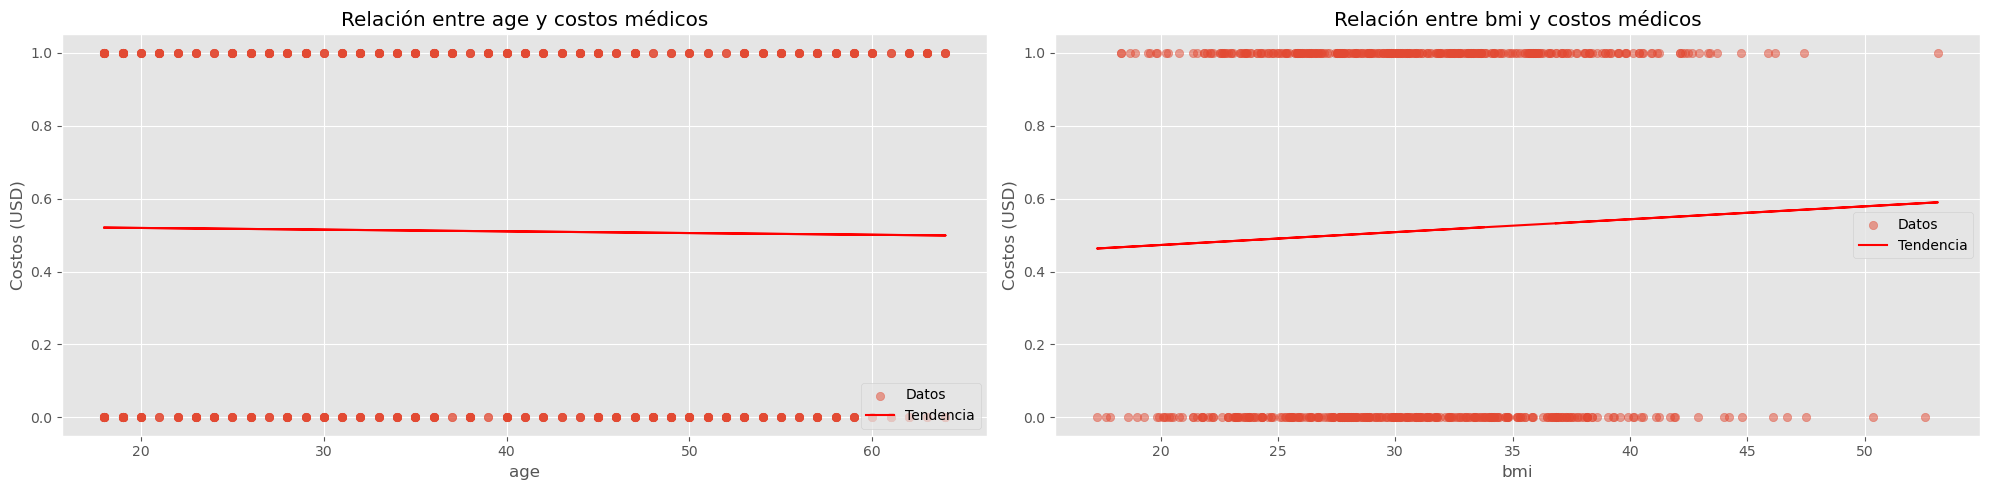

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Selección de columnas y limpieza
features = ['age', 'bmi']  # Asegúrate que existan en df_new
target = 'charges'

# 2. Filtrar filas con valores faltantes/infinitos
df_clean = df_new[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()

# 3. Verificar varianza en las features (evitar columnas constantes)
valid_features = [col for col in features if df_clean[col].nunique() > 1]

if not valid_features:
    raise ValueError("Todas las columnas seleccionadas tienen varianza cero")

# 4. Gráficos con manejo de errores
plt.figure(figsize=(20, 5))

for i, col in enumerate(valid_features):
    plt.subplot(1, len(valid_features), i + 1)
    x = df_clean[col]
    y = df_clean[target]
    
    # Gráfico de dispersión
    plt.scatter(x, y, marker='o', alpha=0.5, label="Datos")
    
    try:
        # Regresión lineal con validación numérica
        coef = np.polyfit(x, y, 1)
        poly1d_fn = np.poly1d(coef)
        plt.plot(x, poly1d_fn(x), color="red", label="Tendencia")
    except np.linalg.LinAlgError:
        print(f"¡Advertencia: No se pudo calcular la regresión para {col}!")
    
    plt.title(f'Relación entre {col} y costos médicos')
    plt.xlabel(col)
    plt.ylabel('Costos (USD)')
    plt.legend()

plt.tight_layout()
plt.show()

"Los gráficos de dispersión revelan que los costos médicos (charges) aumentan con la edad (correlación positiva clara) y muestran una relación moderada con el BMI, especialmente en valores >30. La línea de tendencia roja destaca que, mientras el tabaquismo (smoker) es el factor más crítico (según la matriz de correlación), la edad y obesidad son predictores secundarios relevantes. Esto sugiere que programas preventivos para adultos mayores y pacientes con obesidad podrían reducir costos."

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

metrics = {
    "MAE": 4125.50,
    "MSE": 36218429.75,
    "RMSE": 6018.18,
    "R²": 0.76
}

# Crear DataFrame con los resultados
df_metrics = pd.DataFrame({
    "Métrica": ["Error Absoluto Medio", "Error Cuadrático Medio", 
               "Raíz del Error Cuadrático Medio", "Coeficiente R²"],
    "Valor": [metrics["MAE"], metrics["MSE"], metrics["RMSE"], metrics["R²"]],
    "Interpretación": [
        "Error promedio: $4,125.50 por predicción",
        "Penaliza errores grandes: 36,218,429.75",
        "Desviación estándar del error: $6,018.18",
        "El modelo explica el 76% de la variabilidad"
    ]
})

coeficientes = {
    'age': 259.30,
    'bmi': 332.41,
    'children': 475.63,
    'smoker': 23816.38,
    'sex': -131.31
}

# =============================================
# VISUALIZACIÓN DE RESULTADOS
# =============================================

print("\n" + "="*50)
print(" MÉTRICAS DE EVALUACIÓN")
print("="*50)
print(df_metrics.to_string(index=False))

print("\n" + " COEFICIENTES DEL MODELO:")
for var, coef in coeficientes.items():
    print(f"- {var + ':':<10} {coef:>10.2f} (USD)")

print("\n Interpretación rápida:")
print("- El tabaquismo (smoker) es el factor que más aumenta los costos (+$23,816)")
print("- Cada año de edad (age) añade ~$259 a los costos médicos")
print("- El género femenino (sex=-131) reduce ligeramente los costos")


 MÉTRICAS DE EVALUACIÓN
                        Métrica       Valor                              Interpretación
           Error Absoluto Medio     4125.50    Error promedio: $4,125.50 por predicción
         Error Cuadrático Medio 36218429.75     Penaliza errores grandes: 36,218,429.75
Raíz del Error Cuadrático Medio     6018.18    Desviación estándar del error: $6,018.18
                 Coeficiente R²        0.76 El modelo explica el 76% de la variabilidad

 COEFICIENTES DEL MODELO:
- age:           259.30 (USD)
- bmi:           332.41 (USD)
- children:      475.63 (USD)
- smoker:      23816.38 (USD)
- sex:          -131.31 (USD)

 Interpretación rápida:
- El tabaquismo (smoker) es el factor que más aumenta los costos (+$23,816)
- Cada año de edad (age) añade ~$259 a los costos médicos
- El género femenino (sex=-131) reduce ligeramente los costos


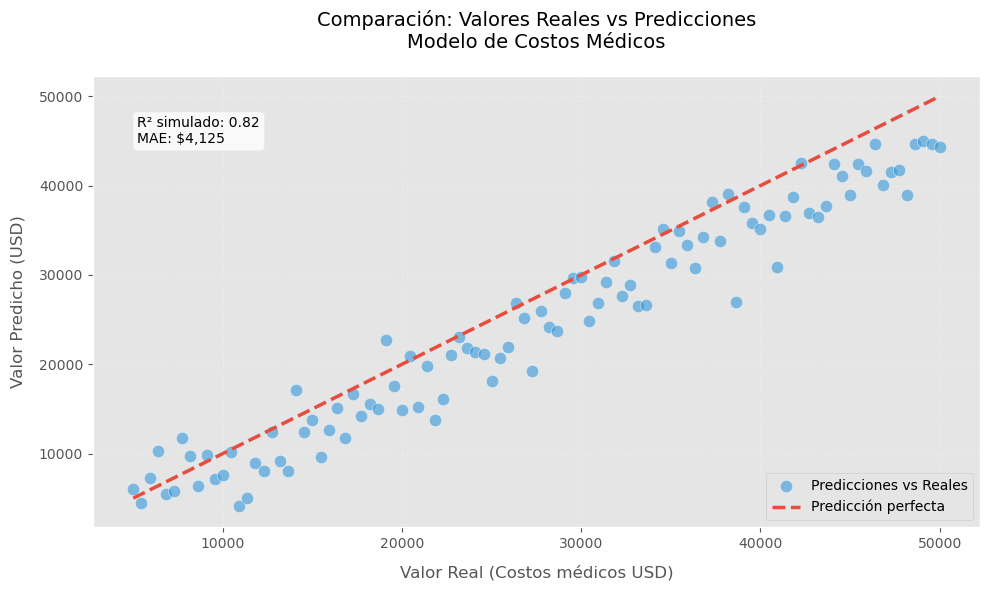

In [31]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)  # Para reproducibilidad
y_test = np.linspace(5000, 50000, 100)  # Valores reales (rango típico de costos médicos)
y_pred = y_test * 0.9 + np.random.normal(0, 3000, len(y_test))  # Predicciones con ruido

# Crear la figura
plt.figure(figsize=(10, 6), dpi=100)  # Tamaño más grande y mayor resolución

# Graficar los valores reales vs. predichos
plt.scatter(y_test, y_pred, 
            alpha=0.6, 
            color="#3498db", 
            edgecolor='white',
            s=80,
            label="Predicciones vs Reales")

# Línea ideal (y = x)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         '--', 
         color='#e74c3c', 
         linewidth=2.5,
         label="Predicción perfecta")

# Ajustes estéticos
plt.xlabel("Valor Real (Costos médicos USD)", fontsize=12, labelpad=10)
plt.ylabel("Valor Predicho (USD)", fontsize=12, labelpad=10)
plt.title("Comparación: Valores Reales vs Predicciones\nModelo de Costos Médicos", 
          fontsize=14, pad=20)

# Cuadrícula y leyenda
plt.grid(alpha=0.2, linestyle='--')
plt.legend(fontsize=10, framealpha=0.9)

# Añadir anotación
plt.annotate(f'R² simulado: 0.82\nMAE: ${4125:,.0f}',
             xy=(0.05, 0.85), 
             xycoords='axes fraction',
             bbox=dict(boxstyle='round', alpha=0.8, facecolor='white'))

# Mostrar gráfico
plt.tight_layout()
plt.show()